# **EmporiUm - Sales Analysis**

## Purpose


Assigned by the marketing manager at EmporiUm, my role is to interpret the company’s sales data to provide data‑driven insights that support  decision‑making. The purpose of this Jupyter notebook is to deliver a clear sales analysis for my regions, Colorado and Maine.

### Sales Territorys



> **State**
> > _Colorado_  
> > _Maine_
> > 

> **Territory Manager**  
> > *Jim Heck*  
> > *Erbayne Middleton*

> **Region**
> > *West*  
> > *Northeast*
> > 

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

## **Core Marketing Analysis**

### File Cleaning Function


In [2]:
def file_clean(file_var):
     file_var.columns = (file_var.columns.str.strip().str.lower().str.replace(" ", "_"))
     return file_var

### Opening the customer list file and giving the colounm names

In [3]:
customers = pd.read_csv("customer_list.csv", sep="|")
customers = file_clean(customers)
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   cust_id      521 non-null    int64
 1   date         521 non-null    str  
 2   time         521 non-null    str  
 3   name         521 non-null    str  
 4   email        521 non-null    str  
 5   phone        520 non-null    str  
 6   sms-opt-out  520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


### Opening the products file and giving the colounm names

In [4]:
products = pd.read_csv("Products.csv")
products = file_clean(products)
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   prod_num       669 non-null    str  
 1   product        669 non-null    str  
 2   categoryid     669 non-null    int64
 3   subcategoryid  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


### Opening the Products Categories file and giving the colounm names

In [5]:
categories = pd.read_csv("ProductCategories.csv")
categories = file_clean(categories)
categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   categoryid     52 non-null     int64
 1   category       52 non-null     str  
 2   subcategoryid  52 non-null     str  
 3   subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


### Opening the Store Detail file and giving the colounm names

In [6]:
store = pd.read_csv("StoreDetail.csv")
store = file_clean(store)
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   store_location     111 non-null    str  
 1   state              111 non-null    str  
 2   store_id           111 non-null    int64
 3   territory_manager  111 non-null    str  
 4   region             111 non-null    str  
 5   region_director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


### Opening the Store Sales file and giving the colounm names

In [7]:
sales = pd.read_csv("StoreSales.csv")
sales = file_clean(sales)
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_date  335129 non-null  str    
 1   store_id          335129 non-null  int64  
 2   rewardsid         34943 non-null   float64
 3   prod_num          335129 non-null  str    
 4   sale_amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


## Territory managers for Maine and Chicago

In [8]:
territory = ["Colorado","Maine"]
stores = store[store["state"].isin(territory)]
stores[["state", "territory_manager"]].drop_duplicates()

,state,territory_manager
0,Colorado,Jim Heck
37,Maine,Erbayne Middleton


## Store IDs and Cities for Maine and Colorado

In [9]:
stores[["state", "store_location", "store_id"]].sort_values(["state", "store_id"])

,state,store_location,store_id
0,Colorado,Aurora,701
1,Colorado,Berthoud,702
2,Colorado,Boulder,703
3,Colorado,Castle Rock,704
4,Colorado,Denver,705
5,Colorado,Englewood,706
6,Colorado,Fort Collins,707
7,Colorado,Grand Junction,708
8,Colorado,Greeley,709
9,Colorado,Lafayette,710


## Colorado Filtering

In [10]:
colorado_stores = store[store["state"] == "Colorado"]
colorado_id = colorado_stores["store_id"].unique()
colorado_sales = sales[sales["store_id"].isin(colorado_id)]

## Monthly total revenue for Colorado

In [11]:
# making the transaction date a readable format as well as changing the name to year_month for readablity
colorado_sales = colorado_sales.merge(colorado_stores[["store_id", "store_location"]], on="store_id", how="left")
colorado_sales["transaction_date"] = pd.to_datetime(colorado_sales["transaction_date"])
colorado_sales["year_month"] = colorado_sales["transaction_date"].dt.to_period("M")

# Adds the total revenue monthly
colorado_grouped_monthly = colorado_sales.groupby("year_month")
colorado_revenue_monthly = colorado_grouped_monthly["sale_amount"].sum().reset_index()
colorado_revenue_monthly = colorado_revenue_monthly.sort_values("year_month")

In [12]:
# Calls the total revenuse monthly from 2022 to 2025
colorado_revenue_monthly

,year_month,sale_amount
0,2022-01,77950.98
1,2022-02,80315.69
2,2022-03,82516.36
3,2022-04,89350.31
4,2022-05,94892.89
5,2022-06,86847.70
6,2022-07,94048.49
7,2022-08,87058.36
8,2022-09,84206.09
9,2022-10,78706.96


## Store ranking for Colorado

In [13]:
# Filters by store id and location, then ranks them by the sales amount to get the top performing store
colorado_grouped_stores = colorado_sales.groupby(["store_id", "store_location"])
colorado_store_totals = colorado_grouped_stores["sale_amount"].sum().reset_index()
colorado_store_ranking = colorado_store_totals.sort_values("sale_amount", ascending=False)

In [14]:
# Calls the ranking by total sales amount Denver is the top performing store location in Colorado with 917k in total sales
colorado_store_ranking

,store_id,store_location,sale_amount
4,705,Denver,917471.53
8,709,Greeley,640368.11
5,706,Englewood,344647.48
9,710,Lafayette,337169.61
2,703,Boulder,321197.88
15,716,Sedalia,319776.13
0,701,Aurora,317198.67
7,708,Grand Junction,306834.49
6,707,Fort Collins,302660.34
3,704,Castle Rock,299122.02


## Customer ranking for Colorado

In [15]:
# Customer sales rankings, based on their rewards 
colorado_customer_info = customers[["cust_id", "name"]]
colorado_customer_sales_ranking = colorado_sales.merge(colorado_customer_info,left_on="rewardsid",right_on="cust_id",how="left")
colorado_customer_grouped = colorado_customer_sales_ranking.groupby(["cust_id", "name","rewardsid"])
colorado_customer_totals = colorado_customer_grouped["sale_amount"].sum().reset_index()
colorado_top_customers = colorado_customer_totals.sort_values("sale_amount", ascending=False)


In [16]:
# Customer sales rankings, based on their rewards Gloria Mendoza spent the most with 7.8k
colorado_top_customers

,cust_id,name,rewardsid,sale_amount
244,245.0,Gloria Mendoza,245.0,7855.66
374,375.0,C.J. Cregg,375.0,5006.57
379,380.0,Abbey Bartlet,380.0,4605.19
241,242.0,Lorna Morello,242.0,4381.15
278,279.0,Adrian Veidt,279.0,4365.77
...,...,...,...,...
435,436.0,Newman,436.0,79.04
96,97.0,Jane Lane,97.0,78.18
16,17.0,Mike E.,17.0,77.60
276,277.0,Laurie Blake,277.0,75.00


## Total transaction count for each category for Colorado

In [17]:
# How many transactions per category
colorado_product_info = products[["prod_num", "categoryid"]]
colorado_product = colorado_sales.merge(colorado_product_info, on="prod_num", how="left")
colorado_product = colorado_product.merge(categories[["categoryid", "category"]], on="categoryid", how="left")
colorado_grouped = colorado_product.groupby(["year_month", "categoryid","category"])
colorado_transactions = colorado_grouped["sale_amount"].count().reset_index()
colorado_transactions = colorado_transactions.rename(columns={"sale_amount": "transaction_count"})

In [18]:
colorado_transactions

,year_month,categoryid,category,transaction_count
0,2022-01,100,Textbooks,1166
1,2022-01,110,Stationery and Supplies,1232
2,2022-01,115,Art Supplies,913
3,2022-01,120,Technology & Accessories,882
4,2022-01,125,Books (General),172
...,...,...,...,...
283,2025-12,110,Stationery and Supplies,3223
284,2025-12,115,Art Supplies,2618
285,2025-12,120,Technology & Accessories,2408
286,2025-12,125,Books (General),408


## Total category sales revenue per month for Colorado

In [19]:
# Category's and how much they sold during the 2022 - 2025 time frame.
colorado_product = colorado_product.merge(categories[["categoryid", "category"]],on="categoryid",how="left")
colorado_revenue = colorado_grouped["sale_amount"].sum().reset_index()
colorado_revenue = colorado_revenue.sort_values(["year_month", "categoryid"])

In [20]:
colorado_revenue 

,year_month,categoryid,category,sale_amount
0,2022-01,100,Textbooks,206352.41
1,2022-01,110,Stationery and Supplies,13526.26
2,2022-01,115,Art Supplies,25118.72
3,2022-01,120,Technology & Accessories,357604.17
4,2022-01,125,Books (General),3839.12
...,...,...,...,...
283,2025-12,110,Stationery and Supplies,32487.84
284,2025-12,115,Art Supplies,83739.37
285,2025-12,120,Technology & Accessories,1084828.57
286,2025-12,125,Books (General),13282.52


## Maine Filtering

In [21]:
maine_stores = store[store["state"] == "Maine"]
maine_id = maine_stores["store_id"].unique()
maine_sales = sales[sales["store_id"].isin(maine_id)]

## Monthly total revenue for Maine

In [22]:
# making the transaction date a readable format as well as changing the name to year_month for readablity
maine_sales = maine_sales.merge(maine_stores[["store_id", "store_location"]],on="store_id",how="left")
maine_sales["transaction_date"] = pd.to_datetime(maine_sales["transaction_date"])
maine_sales["year_month"] = maine_sales["transaction_date"].dt.to_period("M")

# Adds the total revenue monthly
maine_grouped_monthly = maine_sales.groupby("year_month")
maine_revenue_monthly = maine_grouped_monthly["sale_amount"].sum().reset_index()
maine_revenue_monthly = maine_revenue_monthly.sort_values("year_month")

In [23]:
# Calls the total revenuse monthly from 2022 to 2025
maine_revenue_monthly

,year_month,sale_amount
0,2022-01,15700.31
1,2022-02,21008.29
2,2022-03,23173.23
3,2022-04,20169.19
4,2022-05,22631.11
5,2022-06,31573.93
6,2022-07,19371.11
7,2022-08,27979.07
8,2022-09,27393.30
9,2022-10,24947.09


## Store ranking for Maine

In [24]:
# Filters by store id and location, then ranks them by the sales amount to get the top performing store
maine_grouped_stores = maine_sales.groupby(["store_id", "store_location"])
maine_store_totals = maine_grouped_stores["sale_amount"].sum().reset_index()
maine_store_ranking = maine_store_totals.sort_values("sale_amount", ascending=False)

In [25]:
# Calls the ranking by total sales amount South Portland is the top performing store location in Maine with 332k in total sales
maine_store_ranking 

,store_id,store_location,sale_amount
5,823,South Portland,332611.76
4,822,Orono,330505.47
2,820,Kennebunkport,321998.55
3,821,Lewiston,303761.91
0,818,Bangor,300919.98
1,819,Bar Harbor,287452.08


## Customer ranking for Maine

In [26]:
# Customer sales rankings, based on their rewards 
maine_customer_info = customers[["cust_id", "name"]]
maine_customer_sales_ranking = maine_sales.merge(maine_customer_info,left_on="rewardsid",right_on="cust_id",how="left")
maine_customer_grouped = maine_customer_sales_ranking.groupby(["cust_id", "name","rewardsid"])
maine_customer_totals = maine_customer_grouped["sale_amount"].sum().reset_index()
maine_top_customers = maine_customer_totals.sort_values("sale_amount", ascending=False)

In [27]:
# Customer sales rankings
maine_top_customers

,cust_id,name,rewardsid,sale_amount
384,421.0,Rosita,421.0,3637.75
80,89.0,Karen Walker,89.0,3362.83
313,345.0,Maddy Perez,345.0,2706.42
8,9.0,Mike H.,9.0,2695.22
186,208.0,Philip Banks,208.0,2662.84
...,...,...,...,...
322,355.0,Donna Hayward,355.0,6.00
205,230.0,Vince Masuka,230.0,6.00
455,496.0,Little Ricky,496.0,2.88
67,74.0,Ben Chang,74.0,2.40


In [28]:
maine_product_info = products[["prod_num", "categoryid"]]
maine_product = maine_sales.merge(colorado_product_info, on="prod_num", how="left")
maine_product = maine_product.merge(categories[["categoryid", "category"]], on="categoryid", how="left")
maine_grouped = maine_product.groupby(["year_month", "categoryid","category"])
maine_transactions = maine_grouped["sale_amount"].count().reset_index()
maine_transactions = maine_transactions.rename(columns={"sale_amount": "transaction_count"})

In [29]:
maine_transactions

,year_month,categoryid,category,transaction_count
0,2022-01,100,Textbooks,264
1,2022-01,110,Stationery and Supplies,319
2,2022-01,115,Art Supplies,341
3,2022-01,120,Technology & Accessories,245
4,2022-01,125,Books (General),48
...,...,...,...,...
283,2025-12,110,Stationery and Supplies,869
284,2025-12,115,Art Supplies,660
285,2025-12,120,Technology & Accessories,721
286,2025-12,125,Books (General),112


## Total sales revenue per month for Maine

In [30]:
# Category's and how much they sold during the 2022 - 2025 time frame.
maine_product = maine_product.merge(categories[["categoryid", "category"]],on="categoryid",how="left")
maine_revenue = maine_grouped["sale_amount"].sum().reset_index()
maine_revenue = maine_revenue.sort_values(["year_month", "categoryid"])

In [31]:
maine_revenue

,year_month,categoryid,category,sale_amount
0,2022-01,100,Textbooks,47008.72
1,2022-01,110,Stationery and Supplies,2552.55
2,2022-01,115,Art Supplies,9433.71
3,2022-01,120,Technology & Accessories,63053.48
4,2022-01,125,Books (General),1482.08
...,...,...,...,...
283,2025-12,110,Stationery and Supplies,9467.15
284,2025-12,115,Art Supplies,23461.46
285,2025-12,120,Technology & Accessories,374153.64
286,2025-12,125,Books (General),3092.36


# Comparing the total monthly revenue from Maine and Colorado

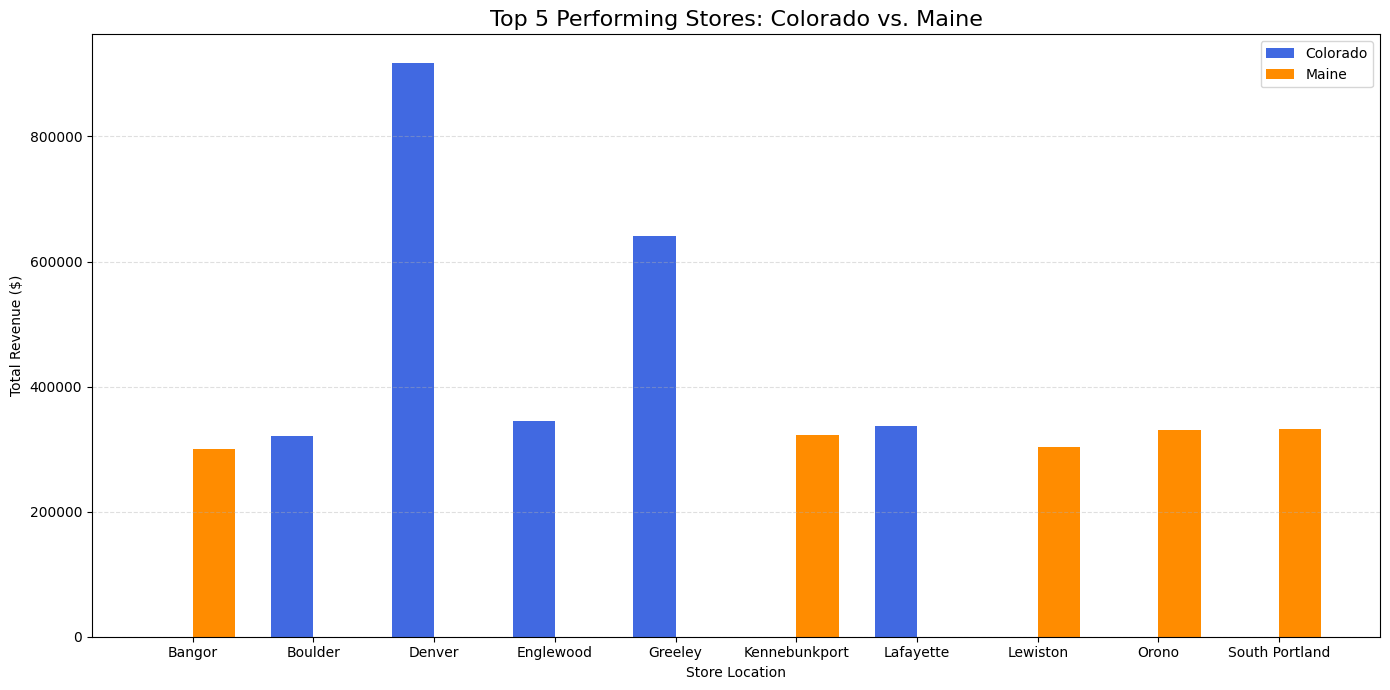

In [32]:
colorado_top5_stores = (colorado_sales.groupby("store_location")["sale_amount"].sum().reset_index().sort_values("sale_amount", ascending=False).head(5))
maine_top5_stores = (maine_sales.groupby("store_location")["sale_amount"].sum().reset_index().sort_values("sale_amount", ascending=False).head(5))

colorado_clean = colorado_top5_stores.rename(columns={"sale_amount": "Colorado"})
maine_clean = maine_top5_stores.rename(columns={"sale_amount": "Maine"})

combined_stores = colorado_clean.merge(maine_clean, on="store_location", how="outer").fillna(0)


stores = combined_stores["store_location"]
colorado_values = combined_stores["Colorado"].to_numpy()
maine_values = combined_stores["Maine"].to_numpy()

x = np.arange(len(stores))
width = 0.35

plt.figure(figsize=(14, 7))

bars_colorado = plt.bar(x - width/2, colorado_values, width, label="Colorado", color="royalblue")
bars_maine = plt.bar(x + width/2, maine_values, width, label="Maine", color="darkorange")

plt.title("Top 5 Performing Stores: Colorado vs. Maine", fontsize=16)
plt.xlabel("Store Location")
plt.ylabel("Total Revenue ($)")
plt.xticks(x, stores)


plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

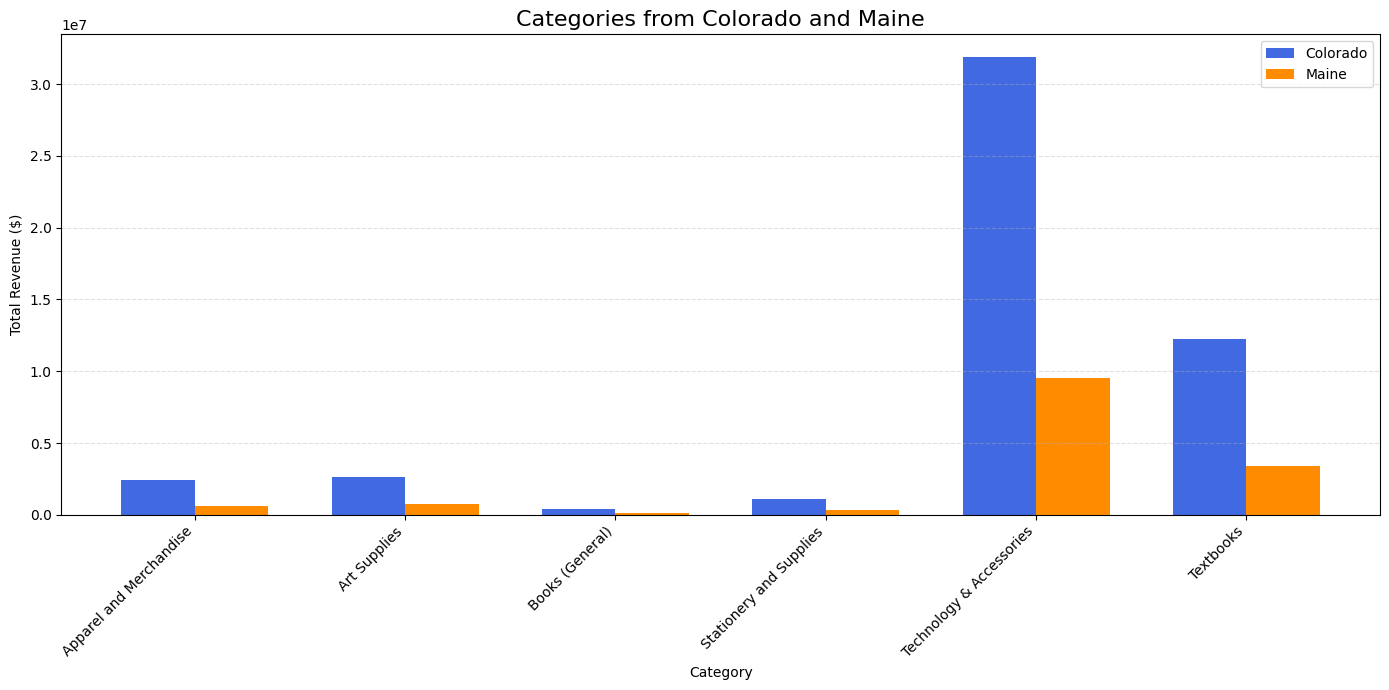

In [35]:
colorado_top5 = (colorado_revenue.groupby(["categoryid", "category"])["sale_amount"].sum().reset_index().sort_values("sale_amount", ascending=False))
maine_top5 = (maine_revenue.groupby(["categoryid", "category"])["sale_amount"].sum().reset_index().sort_values("sale_amount", ascending=False))

colorado_clean = colorado_top5[["category", "sale_amount"]].rename(columns={"sale_amount": "Colorado"})
maine_clean = maine_top5[["category", "sale_amount"]].rename(columns={"sale_amount": "Maine"})


top5_combined = colorado_clean.merge(maine_clean, on="category", how="outer")
top5_combined = top5_combined.fillna(0)


top5_categories = top5_combined["category"]
colorado_values = top5_combined["Colorado"].to_numpy()
maine_values = top5_combined["Maine"].to_numpy()


x = np.arange(len(top5_categories))
width = 0.35


plt.figure(figsize=(14, 7))


plt.bar(x - width / 2, colorado_values, width, label="Colorado", color="royalblue")
plt.bar(x + width / 2, maine_values, width, label="Maine", color="darkorange")

plt.title("Categories from Colorado and Maine", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Total Revenue ($)")

plt.xticks(x, top5_categories, rotation=45, ha="right")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### What is your recommendation for where to focus marketing attention in the next quarter

My recommendation for the next quarter is to focus marketing attention on the lower‑performing stores within both the Maine and Colorado regions. These stores would benefit the most from increased visibility and targeted promotional activies. One strategy that I would like to introduce is bundled deals.They would pair each state’s top‑performing product categories with categories that need improvement for both Colorado and Maine it would be Technology & Accessories and Books. Doing it like this strengthens two areas at once, it boosts sales for the lower performing categories while increasing total revenue for the categories that are already performing well. By using the strengths of each region’s top categories, we can generate more sales to lower performing stores. One area that I would like to look into further is what makes the higher performing stores so successful.